# Deteccion Automatica de Anomalias en KPIs Financieros

**Diferencia clave con los casos anteriores**: este es aprendizaje no supervisado.
No existe etiqueta previa. El algoritmo genera su propio criterio de inusualidad.

| Supervision | Etiqueta | Validacion | Salida |
|---|---|---|---------|
| Supervisado (churn, riesgo) | Existe en datos historicos | Accuracy, AUC | Decision |
| **No supervisado (este caso)** | **La genera el modelo** | **Cualitativa** | **Senal para investigar** |

**Modelos**: IsolationForest + LocalOutlierFactor (comparativa)
**Variable objetivo**: no existe — el modelo decide que es anomalo

---

## Contexto del caso de negocio

| | |
|---|---|
| **Empresa** | empresa — área financiera y control de gestión |
| **Problema de negocio** | Detectar meses con comportamiento anómalo en los KPIs financieros sin necesidad de definir reglas manuales, para alertar al CFO antes de que el cierre mensual confirme la desviación |
| **Datos disponibles** | 48 meses históricos de 9 KPIs financieros: costes, ingresos, margen, horas imputadas y no facturables, desviación de presupuesto, ratio de subcontratación, proyectos activos y tickets de soporte |
| **Técnica aplicada** | Detección de anomalías no supervisada con Isolation Forest (aísla puntos raros con pocos cortes) y Local Outlier Factor (compara densidad local con vecinos); ambos modelos trabajan sin etiquetas |
| **Salida del modelo** | Etiqueta por mes: normal (1) o anomalía (-1), con score de anomalía para ordenar por severidad; visualización PCA 2D para interpretar los clusters |
| **Valor operativo** | Permite detectar automáticamente meses financieramente atípicos y priorizar la revisión manual solo en los casos marcados, reduciendo el tiempo de auditoría interna |

In [1]:
import os, sys
from pathlib import Path

# Configuracion de entorno: ajusta CWD y descarga datos segun el entorno de ejecucion
_BASE_URL = "https://raw.githubusercontent.com/amador2001/ia-datos/main/"
_CSVS = ["kpis_financieros.csv"]

if "google.colab" in sys.modules:
    import urllib.request
    Path("datos").mkdir(exist_ok=True)
    for _csv in _CSVS:
        _dest = Path("datos") / _csv
        if not _dest.exists():
            urllib.request.urlretrieve(_BASE_URL + _csv, str(_dest))
            print(f"Descargado: {_csv}")
elif "__vsc_ipynb_file__" in dir():
    os.chdir(Path(__vsc_ipynb_file__).parent)
elif not Path("datos").exists():
    for _p in [Path("Jupyter_notebooks"), Path("../Jupyter_notebooks")]:
        if (_p / "datos").exists():
            os.chdir(_p)
            break

print(f"Entorno listo. CWD: {os.getcwd()}")

Entorno listo. CWD: /home/amador/compartido/alh-python/projects/formación_AI_springter/Jupyter_notebooks


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110

# Compatibilidad numpy>=1.24 con sklearn<1.0 (np.int fue eliminado)
if not hasattr(np, 'int'):
    np.int = int

In [3]:
# Cargar el historico de KPIs financieros (48 meses)
df = pd.read_csv("datos/kpis_financieros.csv")

print("Primeras filas del dataset:")
display(df.head(10))

print("\nEstadisticas descriptivas:")
display(df.describe().round(2))

df.info()

print(f"\nPeriodo: {df['fecha'].iloc[0]} a {df['fecha'].iloc[-1]}")
print(f"Total de meses: {len(df)}")

Primeras filas del dataset:


,fecha,coste_total_mes,ingresos_mes,margen_mes,horas_imputadas_mes,horas_no_facturables,desviacion_presupuesto,ratio_subcontratacion,num_proyectos_activos,tickets_soporte_mes
0,2020-01,376994,510335,0.2613,2970,408,0.0431,0.2055,12,166
1,2020-02,291533,400650,0.2724,3331,393,0.0643,0.1528,16,130
2,2020-03,308430,432842,0.2874,2808,363,0.0340,0.1691,20,116
3,2020-04,357419,475187,0.2478,2991,394,0.0290,0.2631,24,107
4,2020-05,308155,448247,0.3125,3243,357,0.0520,0.2207,13,116
5,2020-06,373272,483861,0.2286,2859,499,0.0113,0.1725,17,140
6,2020-07,265291,388953,0.3179,3137,507,0.0211,0.1896,9,145
7,2020-08,341816,242193,-0.4113,1862,1139,-0.0036,0.2922,13,113
8,2020-09,355939,490115,0.2738,3375,389,0.0049,0.2051,20,183
9,2020-10,345215,478623,0.2787,3150,361,0.0685,0.2862,14,122



Estadisticas descriptivas:


,coste_total_mes,ingresos_mes,margen_mes,horas_imputadas_mes,horas_no_facturables,desviacion_presupuesto,ratio_subcontratacion,num_proyectos_activos,tickets_soporte_mes
count,48.00,48.00,48.00,48.00,48.00,48.00,48.00,48.00,48.00
mean,348242.98,477367.73,0.26,3193.12,415.42,0.04,0.24,16.06,128.48
std,42975.73,72466.99,0.12,292.29,128.15,0.07,0.08,5.01,42.18
min,265291.00,242193.00,-0.41,1862.00,257.00,-0.02,0.15,9.00,69.00
25%,320259.00,445369.50,0.25,3061.25,359.25,0.02,0.19,12.00,110.00
50%,346679.50,471031.50,0.27,3239.00,394.00,0.03,0.23,14.50,122.00
75%,362362.50,507736.25,0.30,3400.00,461.50,0.04,0.26,21.00,135.50
max,505706.00,768101.00,0.55,3593.00,1139.00,0.38,0.72,24.00,361.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fecha                   48 non-null     object 
 1   coste_total_mes         48 non-null     int64  
 2   ingresos_mes            48 non-null     int64  
 3   margen_mes              48 non-null     float64
 4   horas_imputadas_mes     48 non-null     int64  
 5   horas_no_facturables    48 non-null     int64  
 6   desviacion_presupuesto  48 non-null     float64
 7   ratio_subcontratacion   48 non-null     float64
 8   num_proyectos_activos   48 non-null     int64  
 9   tickets_soporte_mes     48 non-null     int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 3.9+ KB

Periodo: 2020-01 a 2023-12
Total de meses: 48


### Variables del dataset

| Variable | Unidad | Descripcion |
|---|---|---|
| fecha | YYYY-MM | Mes del registro |
| coste_total_mes | EUR | Costes totales del mes |
| ingresos_mes | EUR | Ingresos facturados en el mes |
| margen_mes | ratio | (ingresos - costes) / ingresos |
| horas_imputadas_mes | horas | Horas de equipo imputadas a proyectos |
| horas_no_facturables | horas | Horas internas no facturadas al cliente |
| desviacion_presupuesto | ratio | Desviacion sobre presupuesto aprobado |
| ratio_subcontratacion | ratio | % de trabajo ejecutado por subcontratistas |
| num_proyectos_activos | entero | Proyectos activos en el mes |
| tickets_soporte_mes | entero | Incidencias de soporte recibidas |

> **5 anomalias conocidas inyectadas** para validar los modelos:
> mes 8 (caida de ingresos), mes 14 (error nomina), mes 24 (boom subcontratacion),
> mes 36 (crisis soporte), mes 42 (ingresos extraordinarios)

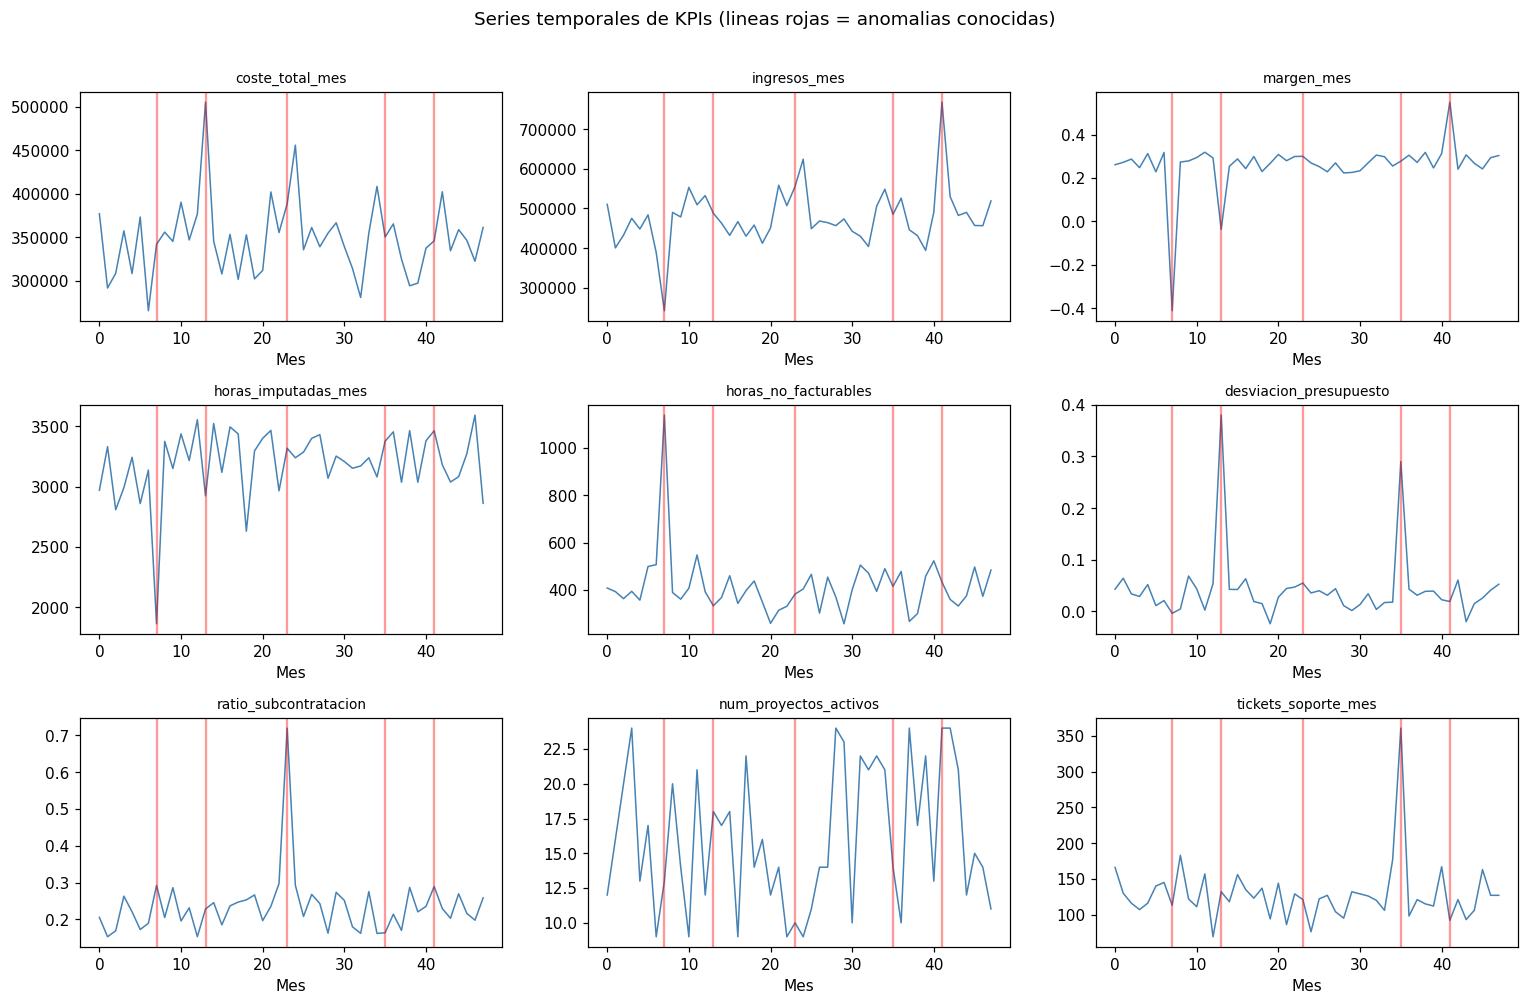

In [4]:
# Visualizar las 9 series temporales para detectar visualmente las anomalias
FEATURES = ["coste_total_mes","ingresos_mes","margen_mes",
            "horas_imputadas_mes","horas_no_facturables","desviacion_presupuesto",
            "ratio_subcontratacion","num_proyectos_activos","tickets_soporte_mes"]

# Meses con anomalias conocidas (indices 0-based: mes 8 = indice 7)
meses_anomalos = [7, 13, 23, 35, 41]

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].plot(range(len(df)), df[feat].to_numpy(), color="steelblue", linewidth=1)
    # Marcar los meses con anomalias conocidas en rojo
    for m in meses_anomalos:
        axes[i].axvline(m, color="red", alpha=0.4, linewidth=1.5)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel("Mes")

plt.suptitle("Series temporales de KPIs (lineas rojas = anomalias conocidas)", y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# Preparar matriz de features (todas las variables numericas excepto fecha)
X = df[FEATURES].copy()

# StandardScaler es OBLIGATORIO para IsolationForest y LOF:
# ambos algoritmos miden distancias, y sin escalar las variables en EUR
# dominian sobre las variables en ratios (0-1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # media=0, std=1 para cada columna

print("Dataset normalizado (primeras 3 filas):")
display(pd.DataFrame(X_scaled, columns=FEATURES).head(3).round(3))

# Split temporal: entrena con los primeros 36 meses, detecta en los ultimos 12
# En anomalia detection no supervisada, el split sirve para validar estabilidad
CORTE = 36
X_train_sc = X_scaled[:CORTE]   # primeros 36 meses (historico "normal")
X_test_sc  = X_scaled[CORTE:]   # ultimos 12 meses (periodo a monitorizar)

print(f"\nMeses de entrenamiento (historico): {CORTE}")
print(f"Meses de evaluacion (monitoreo):    {len(df) - CORTE}")

Dataset normalizado (primeras 3 filas):


,coste_total_mes,ingresos_mes,margen_mes,horas_imputadas_mes,horas_no_facturables,desviacion_presupuesto,ratio_subcontratacion,num_proyectos_activos,tickets_soporte_mes
0,0.676,0.460,0.011,-0.771,-0.058,0.006,-0.358,-0.820,0.899
1,-1.334,-1.070,0.105,0.477,-0.177,0.332,-0.997,-0.013,0.036
2,-0.936,-0.621,0.232,-1.332,-0.413,-0.134,-0.800,0.795,-0.299



Meses de entrenamiento (historico): 36
Meses de evaluacion (monitoreo):    12


In [6]:
# -- Modelo 1: Isolation Forest ----------------------------------------------------
# Construye arboles aleatorios y mide cuantos cortes necesita para aislar un punto.
# Los puntos que se aislan con pocos cortes son anomalias (outliers).
# contamination=0.10 indica que esperamos ~10% de anomalias en los datos.
if_model = IsolationForest(
    n_estimators=200,    # numero de arboles en el ensamble
    contamination=0.10,  # fraccion esperada de anomalias
    random_state=42
)
if_model.fit(X_scaled)   # aprende la distribucion normal del historico completo

# predict() devuelve: 1 = normal, -1 = anomalia
if_labels = if_model.predict(X_scaled)
# decision_function() devuelve el score de anomalia (mas negativo = mas anomalo)
if_scores = if_model.decision_function(X_scaled)

# -- Modelo 2: Local Outlier Factor ------------------------------------------------
# Compara la densidad local de cada punto con la de sus vecinos.
# Un punto en una zona de baja densidad respecto a sus vecinos = anomalia.
lof_model = LocalOutlierFactor(
    n_neighbors=5,       # numero de vecinos para calcular densidad local
    contamination=0.10   # fraccion esperada de anomalias
)
# LOF usa fit_predict() en lugar de fit() + predict() separados
lof_labels = lof_model.fit_predict(X_scaled)

# -- Resumen de detecciones --------------------------------------------------------
df_result = df[["fecha"]].copy()
df_result["if_anomalia"]  = (if_labels  == -1).astype(int)
df_result["lof_anomalia"] = (lof_labels == -1).astype(int)
df_result["anomalia_real"] = 0
for m in meses_anomalos:
    df_result.loc[m, "anomalia_real"] = 1

print("Meses detectados como anomalos por cada modelo:")
display(df_result[df_result[["if_anomalia","lof_anomalia"]].max(axis=1)==1])

print(f"\nIsolation Forest: {df_result['if_anomalia'].sum()} anomalias detectadas")
print(f"LOF:              {df_result['lof_anomalia'].sum()} anomalias detectadas")
print(f"Anomalias reales: {df_result['anomalia_real'].sum()}")

Meses detectados como anomalos por cada modelo:


,fecha,if_anomalia,lof_anomalia,anomalia_real
7,2020-08,1,1,1
13,2021-02,1,1,1
23,2021-12,1,1,1
35,2022-12,1,1,1
41,2023-06,1,1,1



Isolation Forest: 5 anomalias detectadas
LOF:              5 anomalias detectadas
Anomalias reales: 5


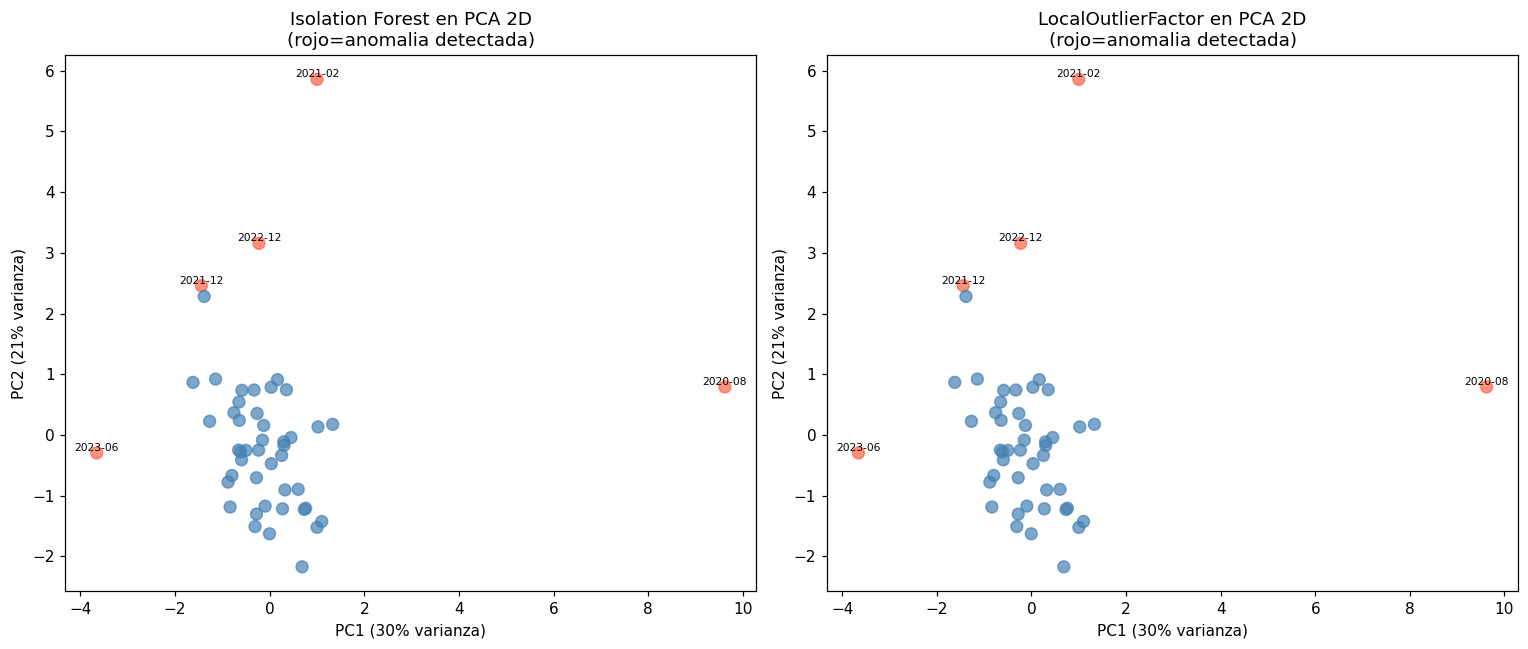

In [7]:
# Reduccion PCA a 2 dimensiones para visualizar los clusters de anomalias
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafica 1: Isolation Forest en 2D (PCA)
colors_if = ["tomato" if l==-1 else "steelblue" for l in if_labels]
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=colors_if, alpha=0.7, s=60)
# Anotar los meses anomalos conocidos
for m in meses_anomalos:
    axes[0].annotate(df.loc[m,"fecha"], (X_pca[m,0], X_pca[m,1]),
                     fontsize=7, ha="center", va="bottom")
axes[0].set_title("Isolation Forest en PCA 2D\n(rojo=anomalia detectada)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza)")

# Grafica 2: LOF en 2D (PCA)
colors_lof = ["tomato" if l==-1 else "steelblue" for l in lof_labels]
axes[1].scatter(X_pca[:,0], X_pca[:,1], c=colors_lof, alpha=0.7, s=60)
for m in meses_anomalos:
    axes[1].annotate(df.loc[m,"fecha"], (X_pca[m,0], X_pca[m,1]),
                     fontsize=7, ha="center", va="bottom")
axes[1].set_title("LocalOutlierFactor en PCA 2D\n(rojo=anomalia detectada)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza)")

plt.tight_layout()
plt.show()

In [8]:
# -- Evaluar un mes nuevo con el modelo entrenado ----------------------------------
# Supongamos que queremos evaluar si el mes actual es anomalo
mes_nuevo = pd.DataFrame([{
    "coste_total_mes":       520000,   # coste inusualmente alto
    "ingresos_mes":          340000,   # ingresos muy bajos (margen negativo)
    "margen_mes":            -0.53,    # margen negativo: perdida
    "horas_imputadas_mes":   2800,
    "horas_no_facturables":  950,      # horas no facturables altas
    "desviacion_presupuesto": 0.45,    # 45% de desviacion sobre presupuesto
    "ratio_subcontratacion": 0.25,
    "num_proyectos_activos": 12,
    "tickets_soporte_mes":   145
}])

# Normalizar el mes nuevo con el mismo scaler (CRITICO: usar transform, no fit_transform)
mes_nuevo_scaled = scaler.transform(mes_nuevo)

# predict() del Isolation Forest: 1=normal, -1=anomalia
resultado = if_model.predict(mes_nuevo_scaled)[0]
score     = if_model.decision_function(mes_nuevo_scaled)[0]

print(f"Score de anomalia (IF): {score:.4f}  (mas negativo = mas anomalo)")
print(f"Clasificacion: {'ANOMALIA DETECTADA' if resultado == -1 else 'Normal'}")
print(f"\nInterpretacion:")
print(f"  Margen negativo + desviacion presupuesto 45%: senales criticas")
print(f"  Accion recomendada: revision inmediata con CFO y PMO")

Score de anomalia (IF): -0.1882  (mas negativo = mas anomalo)
Clasificacion: ANOMALIA DETECTADA

Interpretacion:
  Margen negativo + desviacion presupuesto 45%: senales criticas
  Accion recomendada: revision inmediata con CFO y PMO


### Diferencia fundamental: anomalia estadistica vs problema real

El modelo detecta lo **inusual estadisticamente**, no lo malo per se.

| Evento | Anomalia estadistica? | Problema real? |
|---|---|---|
| Ingresos extraordinarios (+65%) | SI | NO (es bueno) |
| Error en nomina (+50% costes) | SI | SI |
| Caida de ingresos (-45%) | SI | SI |
| Crecimiento sostenido normal | NO | NO |

> **El modelo no decide: alerta.**
> La interpretacion del negocio convierte una senal estadistica en una accion.
> Sin un analista que revise las alertas, el modelo no tiene valor.

### Cuando NO usar deteccion de anomalias no supervisada

| Situacion | Por que no funciona |
|---|---|
| Historico con muchas anomalias (> 20%) | El modelo aprende lo anomalo como normal |
| KPIs con tendencia creciente sin estacionalizar | Detectara los ultimos meses como anomalos siempre |
| Menos de 24 meses de historico | Sin suficiente contexto para definir "normal" |